In [1]:
import os
import pandas as pd
from pathlib import Path
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np
from stardist.models import StarDist2D
from skimage.color import rgb2gray

Import all necessary libraries and display the data from the excel files

In [2]:
images = pd.read_excel(r"C:\Users\gengu\Desktop\jajniki\BRCA_mut_intact_HE_tile_QC.xlsx")
print(images.head())

                                          image_name  \
0  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
1  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
2  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
3  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
4  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   

   Adequate_CA_cell _Quality_1_0  Adequate_staining_quality_1_0  
0                              1                              1  
1                              1                              1  
2                              1                              1  
3                              1                              1  
4                              1                              1  


In [3]:
patients = pd.read_excel(r"C:\Users\gengu\Desktop\jajniki\TCGA WSIs Clinical Data.xlsx")
print(patients.head())

     Patient ID                 BRCA status  HRD Scar Score  Diagnosis Age  \
0  TCGA-23-1021  BRCA2_germline_mutated+LOH        0.966447           45.0   
1  TCGA-23-1022       BRCA1_methylation+LOH        0.994273           67.0   
2  TCGA-23-1023                         NaN             NaN           65.0   
3  TCGA-23-1024                         NaN             NaN           52.0   
4  TCGA-23-1026                         NaN             NaN           45.0   

   Aneuploidy Score Disease-specific Survival status  Fraction Genome Altered  \
0              14.0                1:DEAD WITH TUMOR                   0.8454   
1              12.0                1:DEAD WITH TUMOR                   0.6805   
2               5.0       0:ALIVE OR DEAD TUMOR FREE                   0.2524   
3              16.0       0:ALIVE OR DEAD TUMOR FREE                   0.5751   
4               4.0       0:ALIVE OR DEAD TUMOR FREE                   0.2905   

   MSI MANTIS Score  MSIsensor Score  Mutati

The following is a cell meant to extract the adequacy of staining of each of the provided images, after filtering for both stains to be 1 we have a clean list of all images that can be used for further analysis.

In [4]:
adequate1 = images['Adequate_CA_cell _Quality_1_0'] == 1
adequate2 = images['Adequate_staining_quality_1_0'] == 1
cleandata = images[adequate1 & adequate2]

In [5]:
relevant_patients = patients['BRCA status'].isnull()
Clean_patients = patients[~relevant_patients]
Clean_patients = Clean_patients.iloc[:,0:2]
Clean_patients["BRCA status"] = (Clean_patients['BRCA status'] != 'intact').astype(int)
Clean_patients


,Patient ID,BRCA status
0,TCGA-23-1021,1
1,TCGA-23-1022,1
5,TCGA-23-1027,1
7,TCGA-23-1029,1
8,TCGA-23-1030,0
...,...,...
95,TCGA-59-A5PD,1
96,TCGA-5X-AA5U,0
98,TCGA-OY-A56P,0
99,TCGA-OY-A56Q,0


In [6]:
cleandata['Patient_ID'] = cleandata['image_name'].str.split('-').str[:3].str.join('-')
cleandata = cleandata.loc[:,['Patient_ID','image_name']]
cleandata


1612075917.py (1): 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Patient_ID,image_name
0,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
1,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
2,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
3,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
4,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
...,...,...
1528,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
1529,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
1530,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
1531,TCGA-3P-A9WA,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...


Explanation of cleandata['image_name'].str.split('-').str[:3].str.join('-') for the grandkids:
cleandata['image_name'] is a whole ass column and pandas sees it as a 1D array. when we do the .str it means that on each element of that array the following operation is performed, then we say that the operation is to split with - as the mark to split by. now each string with tcga-blabla-blabla is a list that looks like [tcga, blabla, blabla]. now we have an array of lists. then we use the .str[:3] which means that for each element of the 1d array of list, take the first 3 elements, which signal the patient IDs, then we again do the .str so 'for each element in pandas series' we perform .join and then make the joined patient id. by the way if you just make a cleandata['shittlebongus'] it will add a new ass column named that, no need for defining it earlier lmao.

In [11]:
image_names = cleandata['image_name']
image_names.head()

0    TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
1    TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
2    TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
3    TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
4    TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...
Name: image_name, dtype: object

Now for the actual shit we need to do, let us play with one image and then proceed to make a loop doing the same for all images if it works on just the one

In [12]:
Path_part = r'C:\Users\gengu\Desktop\jajniki\TCGA\_HE_masks_'
base_path = Path(r'C:\Users\gengu\Desktop\jajniki\TCGA\_HE_tiles_')
os.environ["KERAS_HOME"] = r"C:\Users\gengu\stardist_models"

For another machine this above part requires getting the filepath to the folder where all the photos are stored, when running on a different machine only this needs to change in order to proceed with no issues. for that last one with os, it needs to be that way in order to avoid errors in 

(1024, 1024, 3) uint8


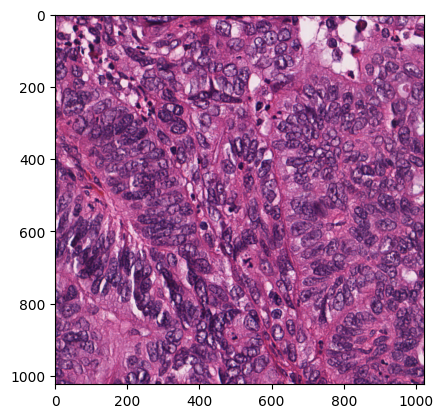

In [13]:
image_name = image_names.iloc[0]
img_path = base_path/image_name
image = imread(img_path)
plt.imshow(image)
print(image.shape , image.dtype)


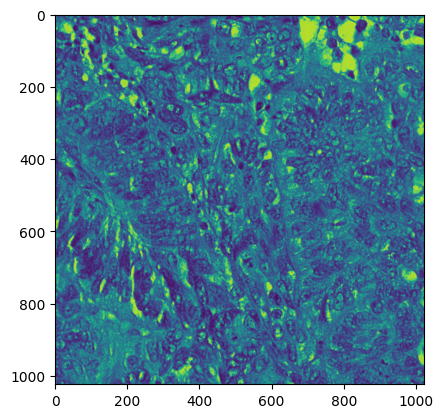

In [15]:
#normalize the image
image_norm = image / image.max()
grey = rgb2gray(image_norm)
plt.imshow(grey)

In [16]:
nucleus_finder2000 = StarDist2D(name="2D_versatile_he_extracted",basedir=r"C:\Users\gengu\.keras\models\StarDist2D\2D_versatile_he")


base_model.py (203): output path for model already exists, files may be overwritten: C:\Users\gengu\.keras\models\StarDist2D\2D_versatile_he\2D_versatile_he_extracted


Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


The pipeline will be the following:
- make it so that we have all the patients listed
- for each patient get all images of that patient
- for each image segment the nuclei
- store the number of nuclei for later use
- for each nucleus find the fdim values
- store each feature value in a variable for later use 
- after each patient image is done, calculate the average value of each of the features for that patient (sum of all nuclei's values divided by number of all nuclei, both of which we stored irl) and assign that value to that patient in a separate table
- reset those variables for counting the averages to 0 to reuse for next patient
- there are only like 100 patients, we can easily check which ones have cancer and which ones don't
- do statistical tests that check if there is a correlation between each average feature and cancer prediction
- visualize statistical test results in pretty graphs and tables


In [ ]:
# NOT FINISHED, DO NOT RUN YET!!!
for patient_id,patient_df in cleandata.groupby('Patient_ID'):
    
    cell_count = 0
    areas = 0

    for image in patient_df:

        image_name = image['image_name']
        image_path = base_path/image_name
        
        img = imread(image_path)
        image_norm = img / img.max()
        grey = rgb2gray(image_norm)

        labels,nuclei = nucleus_finder2000.predict_instances(grey)
        
        probabilities = list(polys["prob"])
        n_detections = len(probabilities)
        cell_count += n_detections
        # we need to do stuff with the labeled nuclei here but this needs to be tested

        

def Process_image(image_name):
    img_path = base_path/image_name
    if not(img_path.exist()):
        print(f'The file {img_path} does not exist')
        return None
    
    return features
